# Import packages

In [1]:
import numpy as np # numerical computing
import matplotlib.pyplot as plt # plotting
import pandas as pd # data handling
from pathlib import Path # file handling
# the code below autoloads new changes (no restart of the kernel needed)
%reload_ext autoreload
%autoreload 2


# Data loading 

* when you download a dataset, always place it in `../data/` so you can easily open it via relative paths
* try loading it via pandas read options, you can check them out by running `pd.*read*?`
    * e.g. load csv-file `../data/trajectories.csv`: run `df = pd.read_csv("../data/trajectories.csv")`
    * now df is a DataFrame, that contains your data and you can work with it

In [2]:
df = pd.read_csv('../data/beesbook_location_data.csv')
# df = df.set_index('Time [frame]')

In [3]:
df.head()

,bee_id,cam_id,cams,timestamp,x_pos_hive,y_pos_hive,location,date
0,2050,3,"(2, 3)",2016-08-13 00:00:00+00:00,314.833,110.1890,other,2016-08-13
1,2052,1,"(0, 1)",2016-08-13 00:00:00+00:00,266.077,29.9148,honey_storage,2016-08-13
2,2056,3,"(2, 3)",2016-08-13 00:00:00+00:00,201.416,151.3450,other,2016-08-13
3,410,3,"(2, 3)",2016-08-13 00:00:00+00:00,212.669,156.9190,other,2016-08-13
4,2066,2,"(2, 3)",2016-08-13 00:00:00+00:00,81.273,83.4977,other,2016-08-13


[Text(0.5, 0, ''), Text(0, 0.5, '# of unique bees detected per day')]

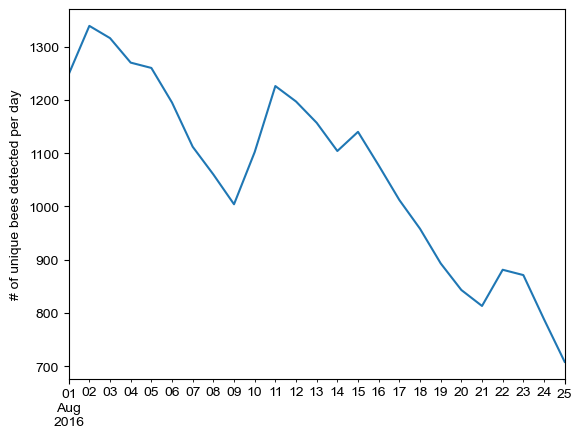

In [4]:
# find the unique bees detected per day
df_ = df[['bee_id', 'date']].drop_duplicates().groupby('date').size()
df_.index = pd.to_datetime(df_.index)
# plot:
f, ax = plt.subplots()
df_.plot(ax=ax)
ax.set(xlabel='', ylabel='# of unique bees detected per day')

[Text(0.5, 0, ''), Text(0, 0.5, '# of unique bees detected per minute')]

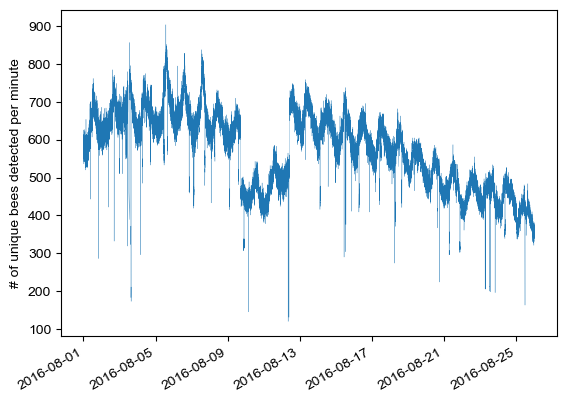

In [5]:
# find the unique bees detected per minute 
df_ = df.groupby('timestamp').size()
df_.index = pd.to_datetime(df_.index)
# plot:
f, ax = plt.subplots()
df_.plot(ax=ax, linewidth=0.2)
ax.set(xlabel='', ylabel='# of unique bees detected per minute')

# Data preprocessing 

* some data needs to be preprocessed/cleaned
    * for example if it contains nans
    * useful commands are:
        * `df.head()` : shows first 5 rows 
        * `df.tail()` : shows last 5 rows
        * `df.isna().sum()` : shows for each column the number of nans it contains
        * `df.isna().sum()` : shows for each column the number of nans it contains
        * `df.dopna()`: drops rows if they contain nans (attention, full row is dropped even if only 1 column contains nan)

## Shift the position of the back of the hive
we do a trick to not need to distinguish between front and back side

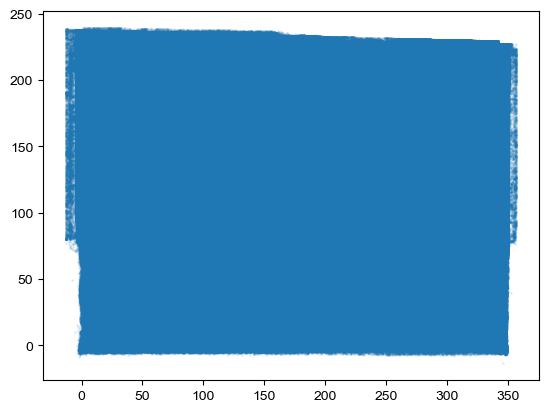

In [6]:
# Plot all data points
plt.scatter(df['x_pos_hive'], df['y_pos_hive'], s=1, alpha=0.1)

In [7]:
# set the lower left corner to (0, 0)
df['x_pos_hive'] -= df['x_pos_hive'].min()
df['y_pos_hive'] -= df['y_pos_hive'].min()
df['x_pos_hive'].min(), df['y_pos_hive'].min()

(np.float64(0.0), np.float64(0.0))

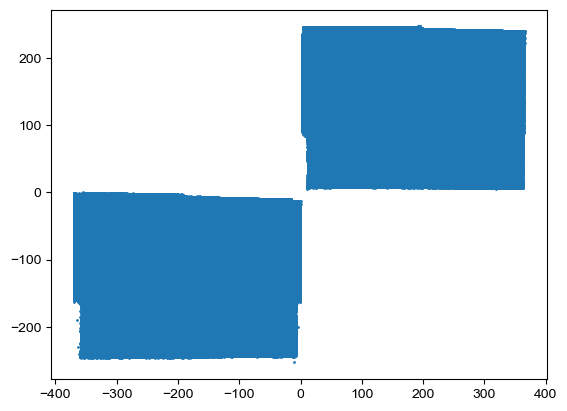

In [8]:
# create a mask that is True if the position is on the back of the hive
mask_back = df['cams'] == '(2, 3)'
# shift the back of the hive to the 3rd quadrant
df.loc[mask_back, 'x_pos_hive'] -= df['x_pos_hive'].max()
df.loc[mask_back, 'y_pos_hive'] -= df['y_pos_hive'].max()
# to verify, plot the positions again
plt.scatter(df['x_pos_hive'], df['y_pos_hive'], s=1)

# Data analysis

## create the grid_cells 
* remember we want to quantify the behavior by the occupation pattern
* the coarser the pattern, the less resolved is the spatial information
    * e.g. bin_size = 400 results in only being able to distinguish between front and back

In [9]:
bin_size = 50
n_x_bins = int( (df['x_pos_hive'].max() - df['x_pos_hive'].min()) / bin_size)
n_y_bins = int( (df['y_pos_hive'].max() - df['y_pos_hive'].min()) / bin_size)
n_x_bins, n_y_bins

(14, 10)

In [10]:
df['x_bin'] = pd.cut(df['x_pos_hive'], bins=n_x_bins, labels=False)
df['y_bin'] = pd.cut(df['y_pos_hive'], bins=n_y_bins, labels=False)

In [11]:
df.head()

,bee_id,cam_id,cams,timestamp,x_pos_hive,y_pos_hive,location,date,x_bin,y_bin
0,2050,3,"(2, 3)",2016-08-13 00:00:00+00:00,-42.1890,-129.4650,other,2016-08-13,6,2
1,2052,1,"(0, 1)",2016-08-13 00:00:00+00:00,279.2292,43.5747,honey_storage,2016-08-13,12,5
2,2056,3,"(2, 3)",2016-08-13 00:00:00+00:00,-155.6060,-88.3090,other,2016-08-13,4,3
3,410,3,"(2, 3)",2016-08-13 00:00:00+00:00,-144.3530,-82.7350,other,2016-08-13,4,3
4,2066,2,"(2, 3)",2016-08-13 00:00:00+00:00,-275.7490,-156.1563,other,2016-08-13,1,1


In [12]:
df['grid_cell'] = df["x_bin"].astype(str) + "_" + df["y_bin"].astype(str)

## bee_id and day combination
We know that bees change their task over the time. So we can not simply aggregate on bee_id, but rather on bee_id and day combination, let's call it "bee_day"

In [13]:
# now we compute bee_day (takes a while, roughly 30s and up to 2 minutes)
df['day'] = pd.to_datetime(df['timestamp']).apply(lambda x: x.date().day)
df['bee_day'] = df["bee_id"].astype(str) + "_" + df["day"].astype(str)

In [14]:
df_features = (
    df.groupby(['bee_day', 'grid_cell']
               ).size(
               ).unstack(fill_value=0)
)

[Text(0.5, 0, '# of observation of a specific bee at one day'),
 Text(0, 0.5, '# of bees')]

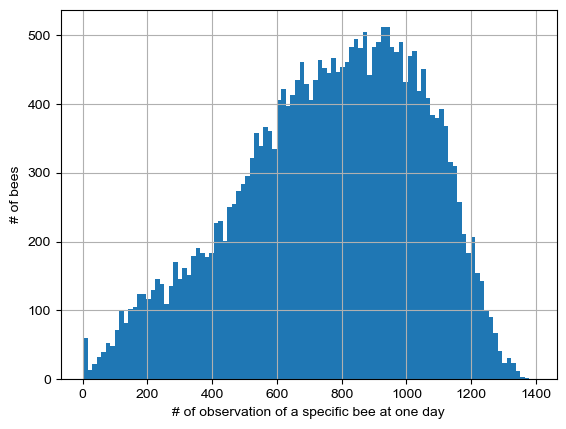

In [15]:
f, ax = plt.subplots()
df_features.sum(axis=1).hist(bins=100, ax=ax)
ax.set(xlabel='# of observation of a specific bee at one day',
       ylabel='# of bees')

In [16]:
# Note from the plot above, the current features has information on how often a bee got detected
# this information is as well interesting but first we want to normalize it
# by dividing by the number of detections
df_features /= df_features.sum(axis=1).values[:, None]

## Cluster by space occupancy

In [17]:
from sklearn.cluster import KMeans
n_cluster = 5
model = KMeans(n_clusters=n_cluster)
df_features[f'cluster'] = model.fit_predict(df_features)
cluster_means = df_features.groupby(f'cluster').mean()

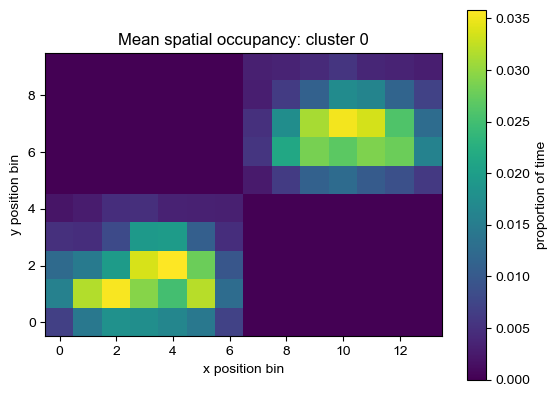

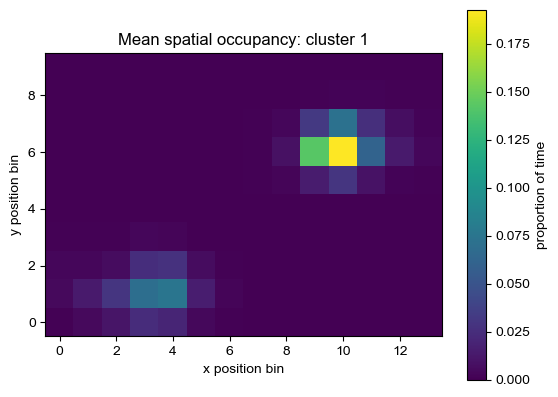

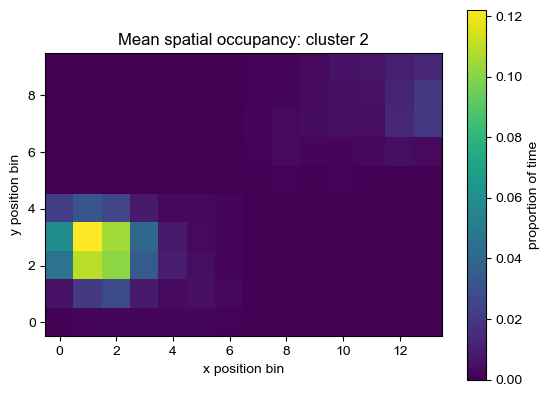

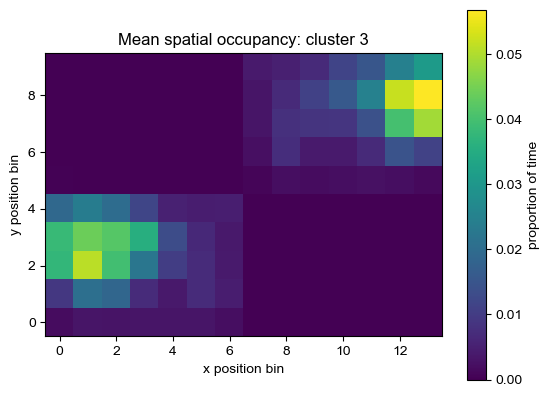

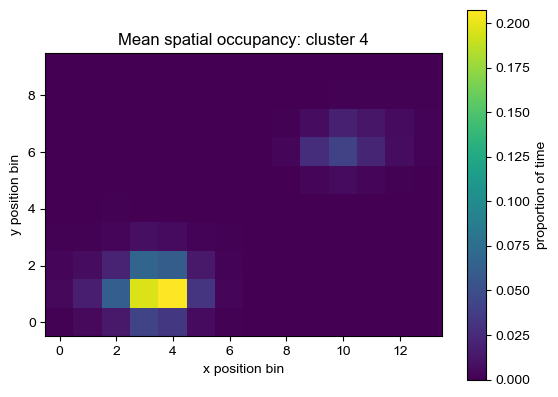

In [18]:
for cluster_id in range(n_cluster):
    mean_profile = cluster_means.loc[cluster_id]

    grid = np.zeros((n_y_bins, n_x_bins))

    for cell, value in mean_profile.items():
        x, y = map(int, cell.split("_"))
        grid[y, x] = value

    f, ax = plt.subplots()
    im = ax.imshow(grid, origin="lower")
    ax.set(title=f"Mean spatial occupancy: cluster {cluster_id}",
           xlabel="x position bin",
           ylabel="y position bin")
    cbar = f.colorbar(im, label="proportion of time")

In [19]:
# we want to know if the occupancy pattern agrees with the labeled
df['x_pos_hive_int'] = df['x_pos_hive'].round().astype('int')
df['y_pos_hive_int'] = df['y_pos_hive'].round().astype('int')

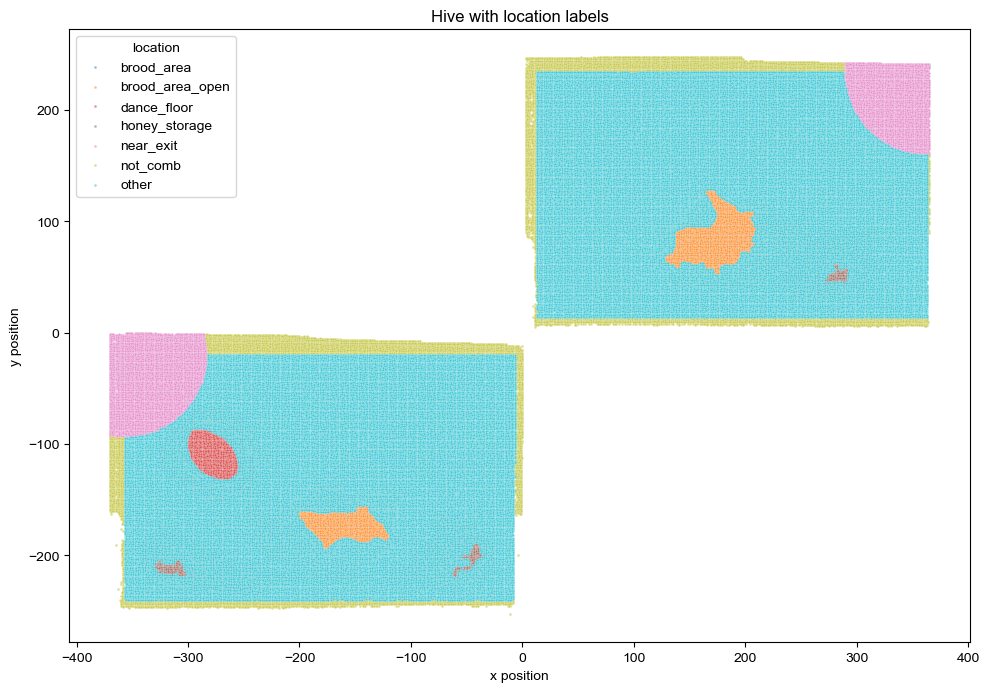

In [20]:
locations = sorted(df["location"].dropna().unique())
colors = plt.get_cmap("tab10", len(locations))
location_colors = {location: colors(i) for i, location in enumerate(locations)}

f, ax = plt.subplots(figsize=(10, 8))

df_ = df[['x_pos_hive_int', 'y_pos_hive_int', 'location']].drop_duplicates()
for location in locations:
    df_loca = df_[df_["location"] == location]
    ax.scatter(
        df_loca["x_pos_hive_int"],
        df_loca["y_pos_hive_int"],
        s=4,
        color=location_colors[location],
        label=location,
        edgecolors="white",
        linewidths=0.3,
        alpha=0.5,
    )
ax.set(xlabel='x position', ylabel='y position', title="Hive with location labels")
ax.legend(title="location", loc="upper left")
ax.set_aspect('equal')
f.tight_layout()